In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor

In [2]:
data = ('car_evaluation.csv')
df= pd.read_csv(data,header=None)

In [3]:
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']


df.columns = col_names

col_names

['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

In [4]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1728 non-null   str  
 1   maint     1728 non-null   str  
 2   doors     1728 non-null   str  
 3   persons   1728 non-null   str  
 4   lug_boot  1728 non-null   str  
 5   safety    1728 non-null   str  
 6   class     1728 non-null   str  
dtypes: str(7)
memory usage: 94.6 KB


# Classifier

In [6]:
X = df.drop(['class'], axis=1)

y = df['class']

In [7]:
xtrain,xtest,ytrain,ytest = train_test_split(X,y,random_state=42,train_size=0.8)

In [8]:
model1 = DecisionTreeClassifier()
model2 = DecisionTreeRegressor()

In [9]:
import category_encoders as ce

encoder = ce.OrdinalEncoder(cols=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety'])


xtrain = encoder.fit_transform(xtrain)

xtest = encoder.transform(xtest)

ModuleNotFoundError: No module named 'category_encoders'

In [ ]:
xtrain.head()


,buying,maint,doors,persons,lug_boot,safety
107,1,1,1,1,1,1
901,2,1,2,2,2,2
1709,3,2,1,3,1,1
706,4,3,3,3,3,2
678,4,3,2,3,3,3


In [ ]:
xtest.head()


,buying,maint,doors,persons,lug_boot,safety
599,4,4,3,3,3,1
1201,2,2,4,2,3,2
628,4,4,1,3,1,2
1498,3,4,1,2,3,2
1263,2,2,3,1,3,3


In [ ]:
#clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0)


# fit the model
model1.fit(xtrain, ytrain)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
y_train_pred = model1.predict(xtrain)


In [ ]:
y_pred_gini = model1.predict(xtest)


In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
import numpy as np

In [ ]:
from sklearn.metrics import classification_report


In [ ]:
print(classification_report(ytrain,y_train_pred))

              precision    recall  f1-score   support

         acc       1.00      1.00      1.00       301
        good       1.00      1.00      1.00        58
       unacc       1.00      1.00      1.00       975
       vgood       1.00      1.00      1.00        48

    accuracy                           1.00      1382
   macro avg       1.00      1.00      1.00      1382
weighted avg       1.00      1.00      1.00      1382



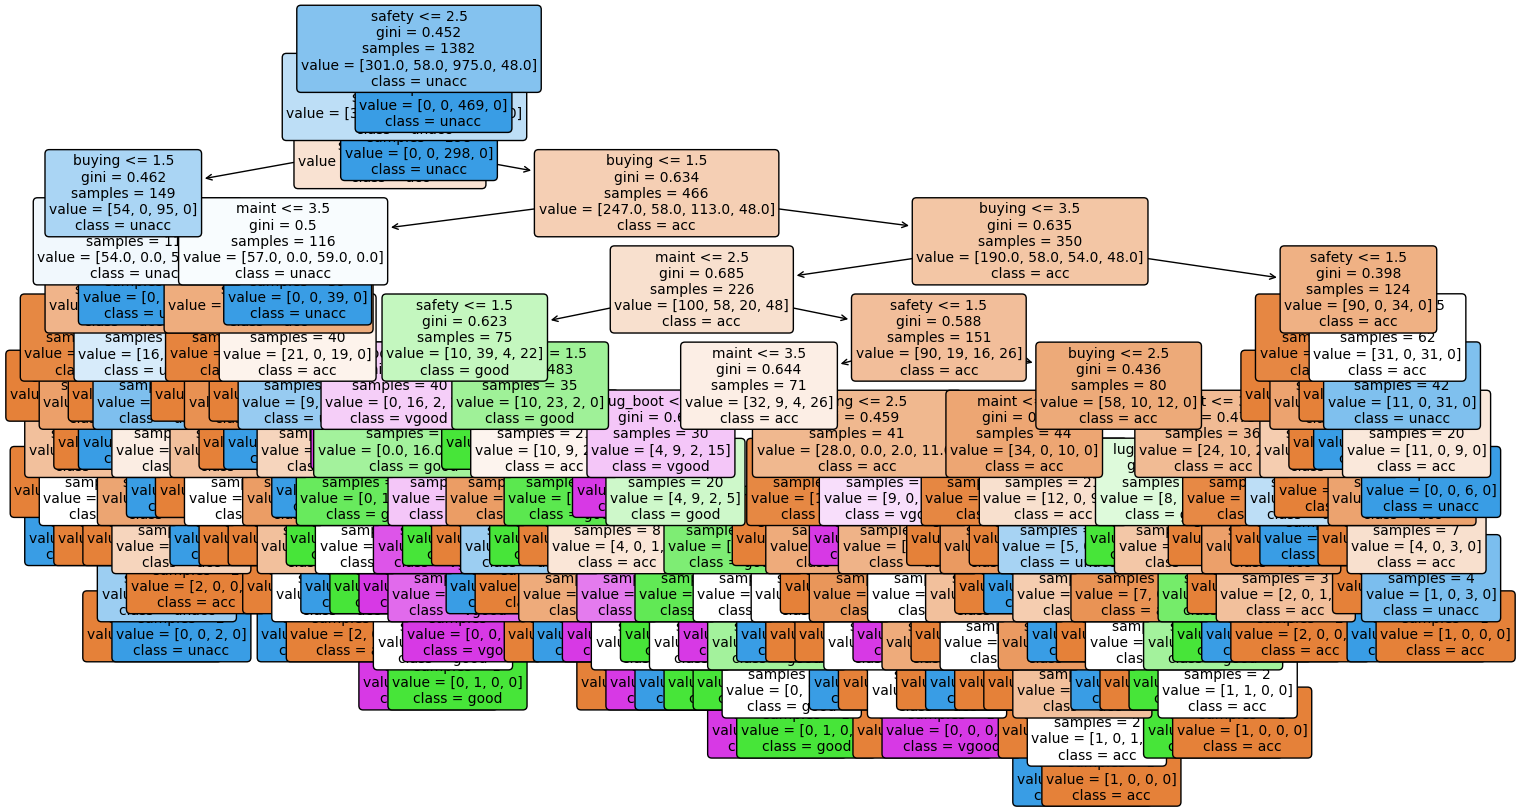

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))

plot_tree(
    model1,
    feature_names=xtrain.columns,
    class_names=model1.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()

# Regressor

In [ ]:
# model2.fit(xtrain, ytrain)
